# Zero-shot streamflow forecasting on the Thames at Kingston

Daily mean discharge from the [UK Environment Agency](https://environment.data.gov.uk/hydrology/) gauge at Kingston-upon-Thames, just upstream of central London (catchment 9,948 km²). The forecast model is [Chronos-2](https://huggingface.co/amazon/chronos-2), a zero-shot foundation model for time series. It sees as much past streamflow + basin-averaged temperature & precipitation as fits in its 8192-token context window (~7.5 years of daily values), then forecasts 15 days ahead conditioned on ensemble weather forecasts — once with NOAA GEFS (31 members), once with ECMWF IFS ENS (51 members).


In [ ]:
!pip install -q dynamical-catalog rioxarray cartopy 'chronos-forecasting[extras]>=2.2' git+https://github.com/kratzert/RivRetrieve-Python.git


## 1. Define the basin

Drainage polygon upstream of the Kingston gauge from the [Global Watersheds API](https://mghydro.com/watersheds/).

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dynamical_catalog
import matplotlib.pyplot as plt
import pandas as pd
import requests
import rioxarray  # noqa: F401  registers .rio accessor
from chronos import BaseChronosPipeline
from shapely.geometry import shape

plt.rcParams.update({"font.size": 16, "axes.titlesize": 18, "axes.labelsize": 16, "legend.fontsize": 14})

GAUGE_LAT, GAUGE_LON = 51.4155, -0.3076  # Kingston, Thames

basin_geojson = requests.get(
    "https://mghydro.com/app/watershed_api",
    params={"lat": GAUGE_LAT, "lng": GAUGE_LON, "precision": "low"},
).json()["features"][0]["geometry"]
basin = shape(basin_geojson).simplify(0.01)
minx, miny, maxx, maxy = basin.bounds

fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([minx - 1, maxx + 1, miny - 0.5, maxy + 0.5])
ax.add_feature(cfeature.LAND, facecolor="#f5f0e8")
ax.add_feature(cfeature.OCEAN, facecolor="#cfe2f3")
ax.add_feature(cfeature.COASTLINE, lw=0.5)
ax.add_feature(cfeature.RIVERS, color="steelblue")
ax.add_geometries([basin], crs=ccrs.PlateCarree(), facecolor="tab:blue", edgecolor="navy", alpha=0.35)
ax.plot(GAUGE_LON, GAUGE_LAT, "k*", markersize=22, transform=ccrs.PlateCarree())
ax.set_title("Thames basin upstream of Kingston gauge")


## 2. Observed streamflow

Daily mean discharge from the EA Hydrology API via [RivRetrieve](https://github.com/kratzert/RivRetrieve-Python), a unified interface to global streamflow data — swap `UKEAFetcher` for `SloveniaFetcher`, `CzechFetcher`, `USAFetcher`, etc. to forecast a different basin.


In [ ]:
from rivretrieve import UKEAFetcher

obs = UKEAFetcher().get_data(
    gauge_id="8496ce69-482c-406a-a2f0-ac418ef8f099",  # Kingston
    variable="discharge_daily_mean",
    start_date="2010-01-01", end_date=str(pd.Timestamp.today().date()),
)["discharge_daily_mean"]

fig, ax = plt.subplots(figsize=(13, 4))
obs.plot(ax=ax, color="black", lw=1)
ax.set_ylabel("Discharge [m³/s]")
ax.set_title(f"Daily mean discharge at Kingston ({obs.index.min().date()} → {obs.index.max().date()})")


## 3. Build covariates and run Chronos-2

We forecast 15 days ahead from `INIT_TIME` conditioned on the past streamflow + GEFS-analysis temperature and precipitation, and on a 15-day ensemble forecast of temperature and precipitation. Each ensemble member produces one streamflow trace — same history, different future weather.


In [ ]:
INIT_TIME = pd.Timestamp("2026-01-08")
FORECAST_DAYS = 15

pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="auto")
HISTORY_DAYS = pipeline.model_context_length // 3  # 1 target + 2 past covariates per day
history_window = slice(INIT_TIME - pd.Timedelta(days=HISTORY_DAYS), INIT_TIME - pd.Timedelta(days=1))


def basin_daily(ds, time_dim):
    """Clip ds to the basin polygon, mean over space, daily-resample. Precip → mm/day."""
    out = (
        ds[["temperature_2m", "precipitation_surface"]]
        .sel(latitude=slice(maxy + 0.5, miny - 0.5), longitude=slice(minx - 0.5, maxx + 0.5))
        .rio.clip([basin], crs="EPSG:4326")
        .mean(dim=("latitude", "longitude"))
        .resample({time_dim: "1D"}).mean()
    )
    out["precipitation_surface"] *= 86_400
    return out.load()


def forecast_meteo(dataset_id):
    return basin_daily(
        dynamical_catalog.open(dataset_id)
            .sel(init_time=INIT_TIME, lead_time=slice("0h", f"{FORECAST_DAYS}d"))
            .swap_dims({"lead_time": "valid_time"}),
        "valid_time",
    ).isel(valid_time=slice(0, FORECAST_DAYS))


analysis_meteo = basin_daily(
    dynamical_catalog.open("noaa-gefs-analysis").sel(time=slice(history_window.start, None)),
    "time",
)
gefs_fc_basin = forecast_meteo("noaa-gefs-forecast-35-day")
ifs_fc_basin = forecast_meteo("ecmwf-ifs-ens-forecast-15-day-0-25-degree")

history_df = pd.concat({
    "discharge_daily_mean": obs,
    "temperature_2m": analysis_meteo["temperature_2m"].to_pandas(),
    "precipitation_surface": analysis_meteo["precipitation_surface"].to_pandas(),
}, axis=1).loc[history_window].dropna().reset_index().rename(columns={"time": "timestamp"})


def forecast_with(future_basin):
    """One Chronos-2 streamflow trace per ensemble member. Returns DataFrame indexed by valid_time, columns by member."""
    members = future_basin["ensemble_member"].astype(str).values
    context = pd.concat([history_df.assign(member=m) for m in members], ignore_index=True)
    future = (
        future_basin.to_dataframe().reset_index()
        .rename(columns={"valid_time": "timestamp", "ensemble_member": "member"})
        [["member", "timestamp", "temperature_2m", "precipitation_surface"]]
        .astype({"member": str})
    )
    pred = pipeline.predict_df(
        context, future_df=future,
        prediction_length=FORECAST_DAYS, quantile_levels=[0.5],
        id_column="member", timestamp_column="timestamp", target="discharge_daily_mean",
    )
    return pred.pivot(index="timestamp", columns="member", values="predictions")


gefs_pred = forecast_with(gefs_fc_basin)
ifs_pred = forecast_with(ifs_fc_basin)


/home/alden/code/dynamical/notebooks/.venv/lib/python3.12/site-packages/chronos/chronos2/dataset.py:89: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  task_target = torch.from_numpy(task_target)


## 4. Forecast plots

Text(0.5, 1.0, 'Chronos-2 forecast — NOAA GEFS covariates (31 members)')

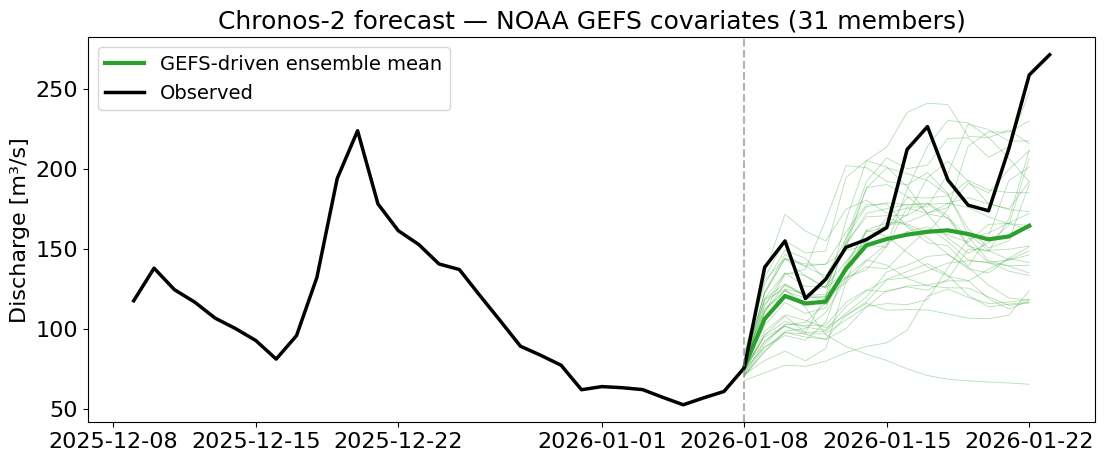

In [ ]:
PLOT_WINDOW = slice(INIT_TIME - pd.Timedelta(days=30), INIT_TIME + pd.Timedelta(days=FORECAST_DAYS))

def plot_traces(ax, pred, color, label):
    ax.plot(pred.index, pred.values, color=color, lw=0.6, alpha=0.35)
    ax.plot(pred.index, pred.mean(axis=1), color=color, lw=3, label=f"{label} ensemble mean")

def plot_obs_and_init(ax):
    ax.plot(obs.loc[PLOT_WINDOW].index, obs.loc[PLOT_WINDOW].values, color="black", lw=2.5, label="Observed")
    ax.axvline(INIT_TIME, color="gray", ls="--", alpha=0.6)
    ax.set_ylabel("Discharge [m³/s]")
    ax.legend(loc="upper left")

fig, ax = plt.subplots(figsize=(13, 5))
plot_traces(ax, gefs_pred, "tab:green", "GEFS-driven")
plot_obs_and_init(ax)
ax.set_title(f"Chronos-2 forecast — NOAA GEFS covariates ({len(gefs_pred.columns)} members)")


Text(0.5, 1.0, 'Chronos-2 forecast — ECMWF IFS ENS covariates (51 members)')

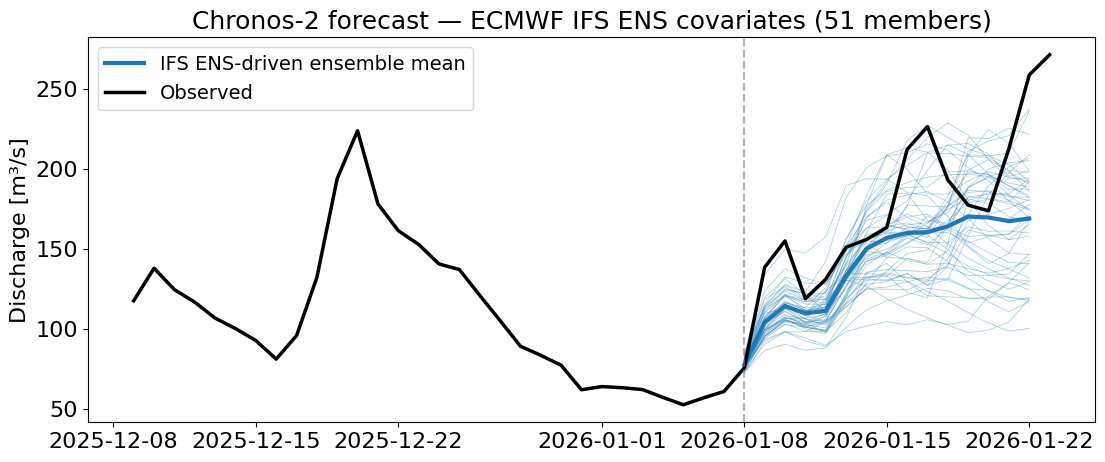

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
plot_traces(ax, ifs_pred, "tab:blue", "IFS ENS-driven")
plot_obs_and_init(ax)
ax.set_title(f"Chronos-2 forecast — ECMWF IFS ENS covariates ({len(ifs_pred.columns)} members)")


Text(0.5, 1.0, 'Chronos-2 zero-shot streamflow forecast initialized 2026-01-08 — Thames at Kingston')

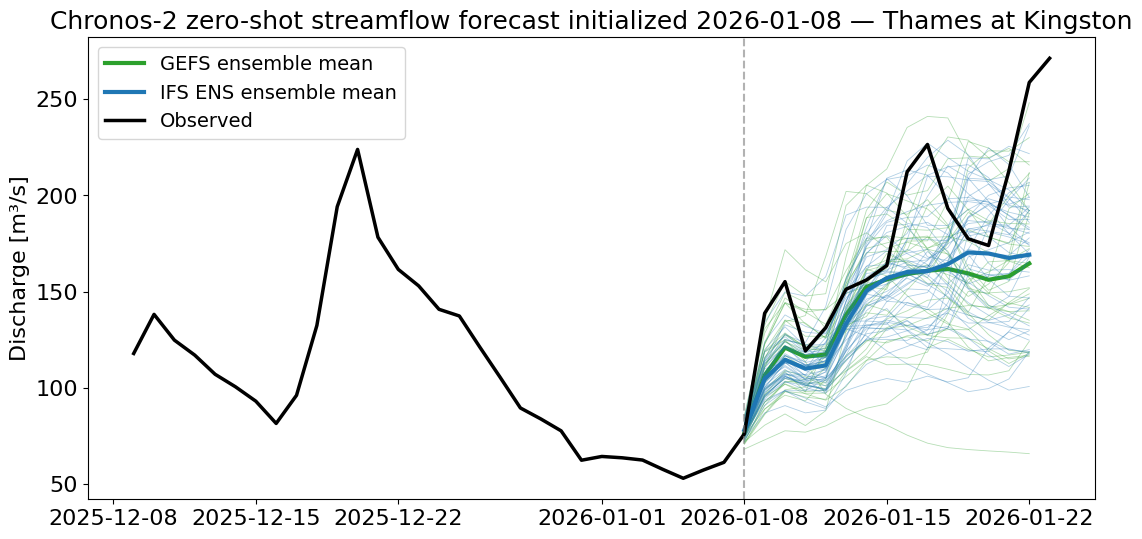

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_traces(ax, gefs_pred, "tab:green", "GEFS")
plot_traces(ax, ifs_pred, "tab:blue", "IFS ENS")
plot_obs_and_init(ax)
ax.set_title(f"Chronos-2 zero-shot streamflow forecast initialized {INIT_TIME.date()} — Thames at Kingston")


Text(0.5, 0.98, 'Basin-mean meteorology and observed streamflow')

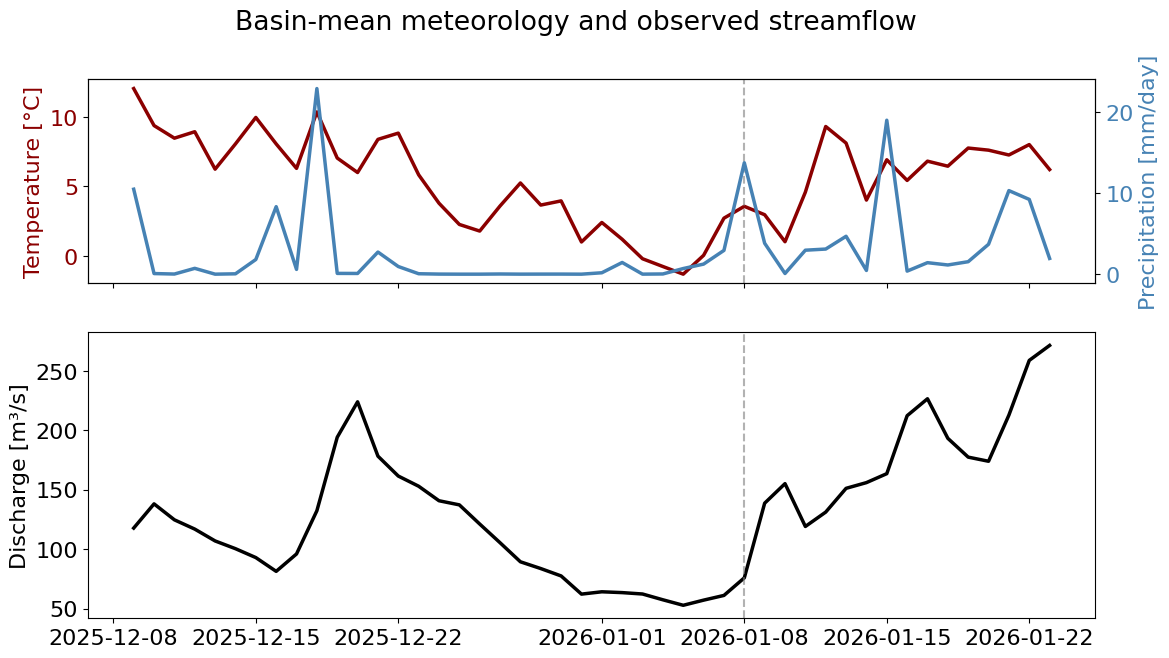

In [ ]:
fig, (ax_meteo, ax_q) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1.4]})

t_hist = analysis_meteo["temperature_2m"].sel(time=PLOT_WINDOW).to_pandas()
p_hist = analysis_meteo["precipitation_surface"].sel(time=PLOT_WINDOW).to_pandas()
ax_meteo.plot(t_hist.index, t_hist.values, color="darkred", lw=2.5)
ax_meteo.set_ylabel("Temperature [°C]", color="darkred")
ax_meteo.tick_params(axis="y", labelcolor="darkred")
ax_p = ax_meteo.twinx()
ax_p.plot(p_hist.index, p_hist.values, color="steelblue", lw=2.5)
ax_p.set_ylabel("Precipitation [mm/day]", color="steelblue")
ax_p.tick_params(axis="y", labelcolor="steelblue")

ax_q.plot(obs.loc[PLOT_WINDOW].index, obs.loc[PLOT_WINDOW].values, color="black", lw=2.5)
ax_q.set_ylabel("Discharge [m³/s]")
for ax in (ax_meteo, ax_q):
    ax.axvline(INIT_TIME, color="gray", ls="--", alpha=0.6)
fig.suptitle("Basin-mean meteorology and observed streamflow")


Text(0.5, 0.98, 'Forecast initialized 2026-01-08 — meteo (analysis + GEFS forecast traces) and Chronos-2 streamflow')

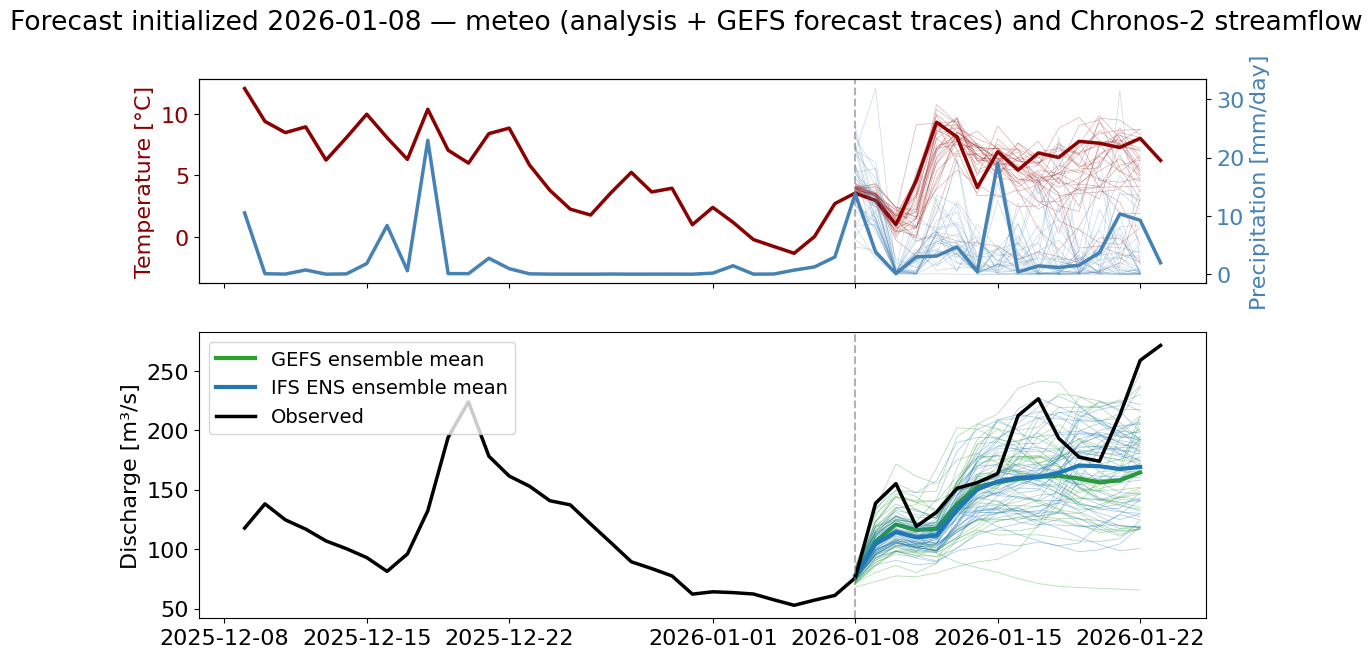

In [ ]:
fig, (ax_meteo, ax_q) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1.4]})

t_hist = analysis_meteo["temperature_2m"].sel(time=PLOT_WINDOW).to_pandas()
p_hist = analysis_meteo["precipitation_surface"].sel(time=PLOT_WINDOW).to_pandas()
gefs_t = gefs_fc_basin["temperature_2m"].transpose("valid_time", "ensemble_member").to_pandas()
gefs_p = gefs_fc_basin["precipitation_surface"].transpose("valid_time", "ensemble_member").to_pandas()

ax_meteo.plot(t_hist.index, t_hist.values, color="darkred", lw=2.5)
ax_meteo.plot(gefs_t.index, gefs_t.values, color="darkred", lw=0.5, alpha=0.3)
ax_meteo.set_ylabel("Temperature [°C]", color="darkred")
ax_meteo.tick_params(axis="y", labelcolor="darkred")
ax_p = ax_meteo.twinx()
ax_p.plot(p_hist.index, p_hist.values, color="steelblue", lw=2.5)
ax_p.plot(gefs_p.index, gefs_p.values, color="steelblue", lw=0.5, alpha=0.3)
ax_p.set_ylabel("Precipitation [mm/day]", color="steelblue")
ax_p.tick_params(axis="y", labelcolor="steelblue")

plot_traces(ax_q, gefs_pred, "tab:green", "GEFS")
plot_traces(ax_q, ifs_pred, "tab:blue", "IFS ENS")
plot_obs_and_init(ax_q)
ax_meteo.axvline(INIT_TIME, color="gray", ls="--", alpha=0.6)
fig.suptitle(f"Forecast initialized {INIT_TIME.date()} — meteo (analysis + GEFS forecast traces) and Chronos-2 streamflow")


## 5. The full context fed to Chronos-2

The basin-mean temperature, precipitation, and observed discharge that fit in the model's 8192-token context window. This is the data the model attends to when producing the forecast.


Text(0.5, 0.98, 'Context fed to Chronos-2 (2018-07-19 → 2026-01-07)')

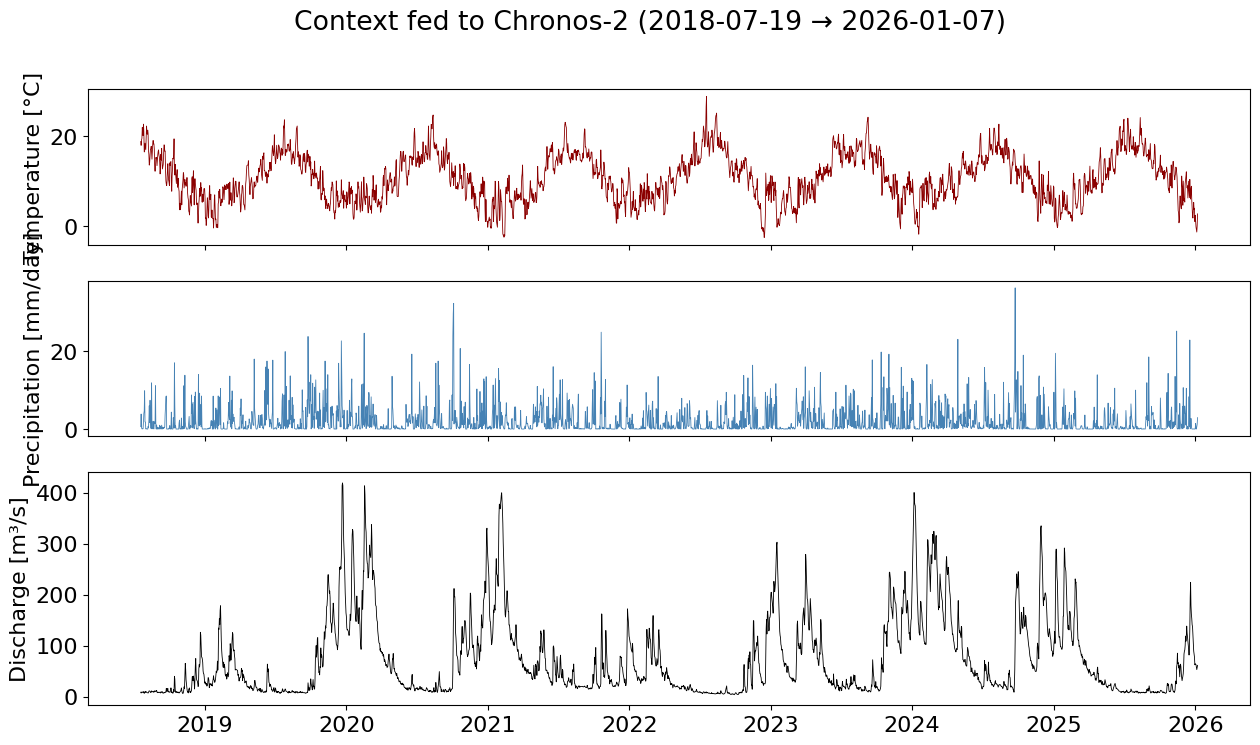

In [ ]:
fig, (ax_t, ax_p, ax_q) = plt.subplots(3, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [1, 1, 1.5]})
t = analysis_meteo["temperature_2m"].sel(time=history_window).to_pandas()
p = analysis_meteo["precipitation_surface"].sel(time=history_window).to_pandas()

ax_t.plot(t.index, t.values, color="darkred", lw=0.6)
ax_t.set_ylabel("Temperature [°C]")
ax_p.plot(p.index, p.values, color="steelblue", lw=0.6)
ax_p.set_ylabel("Precipitation [mm/day]")
ax_q.plot(obs.loc[history_window].index, obs.loc[history_window].values, color="black", lw=0.6)
ax_q.set_ylabel("Discharge [m³/s]")
fig.suptitle(f"Context fed to Chronos-2 ({history_window.start.date()} → {history_window.stop.date()})")
